In [31]:
lsdir('/data/top_complexity/observables')

/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/utils/sorting.py:79: UserWarning: Not all strings contain a number, returning unsorted input list to avoid throwing an error. If you want to only consider strings that contain a digit, set indexed to True 
  warnings.warn("Not all strings contain a number, returning unsorted input list to avoid throwing an error. "


['/data/top_complexity/observables/ab40',
 '/data/top_complexity/observables/actr',
 '/data/top_complexity/observables/asyn']

In [40]:
import torch
import ray
import sys, os
from typing import Optional, Union, List
import multiprocessing
import numpy as np
#import faiss
import mdtraj as md
import matplotlib.pyplot as plt
from seaborn import kdeplot

from writhe_tools.md_tools import (traj_slice, Rg, ResidueDistances,
                                   calc_sa, tangent_corr, bending_energy,
                                   get_residues, to_distance_matrix, to_contacts)

from writhe_tools.md_tools import curvature_menger as curvature
from writhe_tools.utils import lsdir, load_dict, combinations, save_dict, load_dict, group_by, reindex_list, Timer
from writhe_tools.writhe import Writhe, window_average, to_laplacian, filter_writhe_features
from writhe_tools.plots import (subplots_proj2d, subplots_fes2d, lineplot1D,
                                box_plot, plot_distance_matrix, build_matrix_boxplot_grid,
                                build_grid_plot, annotated_matrix_plot, fes2d, proj2d)
from writhe_tools.tcca import tCCA
from writhe_tools.stats import pca, standardize, get_extrema, MaxEntropyReweight, std, mean, rmse, cov

from tools import block_error, ci_filter





obs_paths = lsdir('/data/top_complexity/observables')


names = ['a99',
         'CALVADOS',
         #'bAIes',
         'BioEMU',
         'STARLING',
         #'Coil',
        ]
labels = ['a99SB-disp',
          'CALVADOS',
          #'bAIes',
          'bioemu', 
          'STARLING',
          #'coil',
         ]
need_slice = [True, False, True, True, True, True]
colors = ['steelblue',
          'orange',
          'olivedrab',
          'indianred',
          'gray',
          #'purple',
         ]

protein_names = [ r'A$\beta$40', 'ACTR', r'$\alpha$Synuclein']

helix_pdbs = ['/data/r1r2/kaush/ab40/Ab40_helix.pdb', '/data/writhe/actr/actr.helix.pdb']

#weights_files = [f'{obs_path}/{i}' for i in ['weights_cs', 'weights_pre', 'weights_all']]



from writhe_tools.plots import fes2d, proj2d


# n_classes = len(colors)
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(colors)
bounds = np.arange(0, len(colors) , 1)          # [-0.5, 0.5, 1.5, ...]
norm = BoundaryNorm(bounds, cmap.N)


from writhe_tools.utils import split_list, rm_extension
where_isin = lambda source, key : np.where(np.isin(source, key))[0]
get_where_isin = lambda source, key : source[where_isin(source, key)]
get_name = lambda x : rm_extension(x.split('_')[-1])
# rmsd_matrices = lsdir('./rmsd_matrices')
# rmsd_matrices = np.array([np.asarray(i) for i in split_list(rmsd_matrices, 2)])
# unsorted_names = np.array(list(map(get_name, rmsd_matrices[0])))
# sort = np.array([where_isin(unsorted_names, i).item() for i in names])
# rmsd_matrices = rmsd_matrices[:, sort]

/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/utils/sorting.py:79: UserWarning: Not all strings contain a number, returning unsorted input list to avoid throwing an error. If you want to only consider strings that contain a digit, set indexed to True 
  warnings.warn("Not all strings contain a number, returning unsorted input list to avoid throwing an error. "


In [41]:
files = { 'ab40' : {'pdb' : [
                    "/data/top_complexity/a99/Ab40.pdb",
                    "/data/top_complexity/calvados2_ensembles/Ab40/Ab40_converted.pdb",
                    #"/data/top_complexity/bAIes/Ab40.pdb",
                    "/data/top_complexity/bioemu_ensembles/Ab40/topology_ready.pdb",
                    "/data/top_complexity/starling/ab40/ab40_starling_all.pdb",
                    #"/data/top_complexity/bAIes/Ab40.pdb"
                    
                    
                   ],
           'dcd' : ["/data/top_complexity/a99/Ab40-a99SBdisp-Traj.dcd",
                     "/data/top_complexity/calvados2_ensembles/Ab40/Ab40_converted.xtc",
                     #"/data/top_complexity/bAIes/traj_Ab40_bAIes.xtc",
                     "/data/top_complexity/bioemu_ensembles/Ab40/samples_ready.xtc",
                     "/data/top_complexity/starling/ab40/ab40_starling_all.xtc",
                     #"/data/top_complexity/bAIes/traj_Ab40_coil.xtc",
                   ]  
           
          },
    
    
    
    'actr' : {'pdb' : [
                    "/data/top_complexity/a99/actr.pdb",
                    "/data/top_complexity/calvados2_ensembles/ACTR/ACTR_converted.pdb",
                    #"/data/top_complexity/bAIes/ACTR.pdb",
                    "/data/top_complexity/bioemu_ensembles/ACTR/topology_ready.pdb",
                    "/data/top_complexity/starling/actr/actr_starling_all.pdb",
                    #"/data/top_complexity/bAIes/ACTR.pdb"
    ]
        ,
           'dcd' : [
                   "/data/top_complexity/a99/ACTR-a99SBdisp-Traj.dcd",
                   "/data/top_complexity/calvados2_ensembles/ACTR/ACTR_converted.xtc",
                   #"/data/top_complexity/bAIes/traj_ACTR_bAIes.xtc",
                   "/data/top_complexity/bioemu_ensembles/ACTR/samples_ready.xtc",
                   "/data/top_complexity/starling/actr/actr_starling_all.xtc",
                   #"/data/top_complexity/bAIes/traj_ACTR_coil.xtc"
        ]
          },
 

 'asyn' : {'pdb' : ["/data/top_complexity/a99/asyn_full_lig47_trunc.protein.pdb",  
                    "/data/top_complexity/calvados2_ensembles/asyn/asyn_converted.pdb",
                    "/data/top_complexity/bAIes/asyn.pdb",
                    "/data/top_complexity/bioemu_ensembles/asyn/topology_ready.pdb",
                    "/data/top_complexity/starling/asyn/asyn_starling.pdb",
                    #"/data/top_complexity/bAIes/asyn.pdb",
                   ],
           'dcd' : ["/data/top_complexity/a99/asyn_apo_full.dcd",
                    "/data/top_complexity/calvados2_ensembles/asyn/asyn_converted.xtc",
                    "/data/top_complexity/bAIes/traj_asyn_bAIes.xtc",
                    "/data/top_complexity/bioemu_ensembles/asyn/samples_ready.xtc",
                    "/data/top_complexity/starling/asyn/asyn_starling.xtc",
                    #"/data/top_complexity/bAIes/traj_asyn_coil.xtc"
                           
           ]

     
 }
 
}

In [7]:
xyz = []
for p, d in zip(*list(files['asyn'].values())):
    xyz.append(md.load(d, top=p, atom_indices=md.load(p).top.select('name CA')).center_coordinates().xyz)
save_dict('asyn_xyz.pkl', xyz)
    

/home/t/miniconda3/envs/writhe/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbfile.py:208: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


In [42]:
from tools import ci_filter
import warnings

warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in log",
    category=RuntimeWarning,
)

import warnings
warnings.filterwarnings(
    "ignore",
    message=r"Adding colorbar to a different Figure.*",
    category=UserWarning,
)

# ... then run the code that triggers it


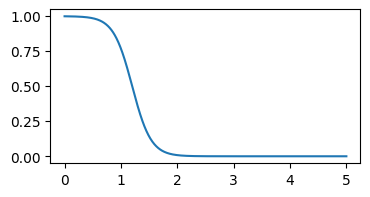

In [7]:
def sigmoid(x, shift=1.2, scale=6):
    return 1 - 1 / (1 + np.exp(-scale * (x - shift)))
x = np.linspace(0, 5, 1000)
plt.figure(figsize=(4, 2))
plt.plot(x, sigmoid(x))


from scipy.signal import find_peaks
def get_best_k(scores):
    k, s = scores.T
    idx = find_peaks(s)[0]
    best_k, score = k[idx][s[idx].argmax()], s[idx].max()
    return best_k, score
#get_best_k(scores)

In [8]:
import numpy as np
import ray


# ============================================================
# Pairwise distances (NumPy only, no (n,n,d) tensor)
# ============================================================

def pairwise_distances_numpy(x: np.ndarray,
                             squared: bool = False,) -> np.ndarray:
    """
    Euclidean pairwise distances using:
        ||x-y||^2 = ||x||^2 + ||y||^2 - 2 x·y
    """
    if x.ndim != 2:
        raise ValueError("data must have shape (n_samples, n_features)")

    x2 = (x * x).sum(axis=1)                      # (n,)
    d2 = x2[:, None] + x2[None, :] - 2.0 * (x @ x.T)
    np.maximum(d2, 0.0, out=d2)
    np.fill_diagonal(d2, 0.0)

    if squared:
        return d2

    return d2 ** (1/2)


# ============================================================
# KMeans++ init (NumPy only)
# ============================================================

def _kmeanspp_init_numpy(x: np.ndarray,
                         n_clusters: int,
                         rng: np.random.Generator) -> np.ndarray:
    n, d = x.shape
    k = int(n_clusters)

    centers = np.empty((k, d), dtype=x.dtype)

    # first center
    i0 = int(rng.integers(0, n))
    centers[0] = x[i0]

    diff = x - centers[0]
    min_d2 = (diff * diff).sum(axis=1)

    for j in range(1, k):
        s = float(min_d2.sum())
        if (s <= 0.0) or (not np.isfinite(s)):
            ij = int(rng.integers(0, n))
        else:
            ij = int(rng.choice(n, p=min_d2 / s))

        centers[j] = x[ij]

        diff = x - centers[j]
        d2_new = (diff * diff).sum(axis=1)
        np.minimum(min_d2, d2_new, out=min_d2)

    return centers


# ============================================================
# KMeans (NumPy only, no one-hot matrix)
# ============================================================

def kmeans_numpy(x: np.ndarray,
                 n_clusters: int,
                 n_init: int = 10,
                 max_iter: int = 100,
                 tol: float = 1e-4,
                 random_state: int = 0):
    """
    Pure NumPy KMeans with k-means++ init.

    Returns
    -------
    labels : (n,) int array
    centers : (k, d) float array
    inertia : float
    """
    if x.ndim != 2:
        raise ValueError("data must have shape (n_samples, n_features)")

    n, d = x.shape
    k = int(n_clusters)

    if k < 2:
        raise ValueError("n_clusters must be >= 2")
    if k > n:
        raise ValueError("n_clusters cannot exceed number of samples")

    x2 = (x * x).sum(axis=1)
    rng_master = np.random.default_rng(random_state)

    best_labels = None
    best_centers = None
    best_inertia = np.inf

    for _ in range(int(n_init)):
        seed = int(rng_master.integers(0, 2**31 - 1))
        rng = np.random.default_rng(seed)

        centers = _kmeanspp_init_numpy(x, k, rng)
        labels_prev = None

        for _ in range(int(max_iter)):
            # assignment step: (n, k) matrix is the unavoidable core object
            c2 = (centers * centers).sum(axis=1)                    # (k,)
            d2 = x2[:, None] + c2[None, :] - 2.0 * (x @ centers.T)  # (n, k)
            np.maximum(d2, 0.0, out=d2)

            labels = np.argmin(d2, axis=1)

            if labels_prev is not None and np.array_equal(labels, labels_prev):
                break

            # update step without one-hot
            sums = np.zeros((k, d), dtype=x.dtype)
            np.add.at(sums, labels, x)

            counts = np.bincount(labels, minlength=k)
            centers_new = centers.copy()

            nonempty = counts > 0
            centers_new[nonempty] = sums[nonempty] / counts[nonempty, None]

            # reseed empty clusters to farthest assigned points
            if np.any(~nonempty):
                assigned_d2 = d2[np.arange(n), labels].copy()
                empty_ids = np.flatnonzero(~nonempty)
                for cid in empty_ids:
                    idx = int(np.argmax(assigned_d2))
                    centers_new[cid] = x[idx]
                    assigned_d2[idx] = -1.0

            shift2 = ((centers_new - centers) ** 2).sum(axis=1)
            centers = centers_new
            labels_prev = labels

            if shift2.size and float(shift2.max()) <= (tol * tol):
                break

        # final assignment for this init
        c2 = (centers * centers).sum(axis=1)
        d2 = x2[:, None] + c2[None, :] - 2.0 * (x @ centers.T)
        np.maximum(d2, 0.0, out=d2)

        labels = np.argmin(d2, axis=1)
        inertia = float(d2[np.arange(n), labels].sum())

        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centers = centers.copy()

    return best_labels, best_centers, best_inertia


# ============================================================
# Silhouette score from precomputed distances (NumPy only)
# No one-hot matrix, no giant D @ M
# ============================================================

def silhouette_score_precomputed_numpy(D: np.ndarray,
                                       labels: np.ndarray) -> float:
    """
    Exact silhouette score from precomputed distance matrix.
    """
    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError("distance_matrix must be square (n, n)")

    n = D.shape[0]
    labels = np.asarray(labels)
    if labels.ndim != 1 or labels.shape[0] != n:
        raise ValueError("labels must have shape (n,)")

    # normalize labels -> 0..k-1
    _, inv = np.unique(labels, return_inverse=True)

    k = int(inv.max()) + 1

    if k < 2 or k >= n:
        raise ValueError("silhouette requires 2 <= n_clusters <= n_samples - 1")

    cluster_indices = [np.flatnonzero(inv == c) for c in range(k)]
    counts = np.array([idx.size for idx in cluster_indices])

    a = np.zeros(n)             # intra-cluster mean dist
    b = np.full(n, np.inf)      # nearest other-cluster mean dist

    singleton = counts[inv] <= 1

    # loop over clusters (small k), vectorize across samples
    for c, idx in enumerate(cluster_indices):
        m = int(idx.size)
        if m == 0:
            continue

        # sum distances from every point to cluster c
        sums = D[:, idx].sum(axis=1)              # (n,)
        mean_to_c = sums / m

        # update b for points not in c
        tmp = mean_to_c.copy()
        tmp[idx] = np.inf
        np.minimum(b, tmp, out=b)

        # update a for points in c
        if m > 1:
            a[idx] = sums[idx] / (m - 1)
        else:
            a[idx] = 0.0

    denom = np.maximum(a, b)
    s = np.zeros(n)

    valid = (~singleton) & (denom > 0.0)
    s[valid] = (b[valid] - a[valid]) / denom[valid]
    s[~valid] = 0.0   # sklearn convention for singleton clusters

    return float(s.mean())


# ============================================================
# Composed NumPy score function (serializable by Ray)
# ============================================================

def score_k_numpy(distance_matrix: np.ndarray,
                  data: np.ndarray,
                  k: int,
                  n_init: int = 10,
                  max_iter: int = 100,
                  tol: float = 1e-4,
                  random_state: int = 0) -> float:
    labels, _, _ = kmeans_numpy(data,
                                n_clusters=int(k),
                                n_init=n_init,
                                max_iter=max_iter,
                                tol=tol,
                                random_state=random_state)
    return silhouette_score_precomputed_numpy(distance_matrix, labels)



# ============================================================
# Convenience wrapper (same spirit as your original)
# ============================================================

def silhouette_scores(data: np.ndarray,
                      k: "int or list",
                      D: np.ndarray = None,
                      parallel: bool = False,
                      n_init: int = 10,
                      max_iter: int = 100,
                      tol: float = 1e-4,
                      random_state: int = 0,
                      dtype=np.float32):
    """
    Compute silhouette score(s) for one or many k using pure NumPy KMeans + silhouette.
    Optional Ray parallelization across k.

    Returns
    -------
    if k is int:
        [k, score]
    else:
        ndarray shape (len(k), 2): columns [k, score]
    """
    if data.ndim != 2:
        raise ValueError("data must have shape (n_samples, n_features)")

    if D is not None:
        assert D.shape == (data.shape[0], data.shape[0]), 'Must provide a n_samples by n_samples distance matrix or leave to None'
    else:
        D = pairwise_distances_numpy(data, squared=False) 

    # scalar path
    if np.isscalar(k):
        ki = int(k)
        return [ki, score_k_numpy(D, data, ki,
                                  n_init=n_init,
                                  max_iter=max_iter,
                                  tol=tol,
                                  random_state=random_state)]

    ks = [int(i) for i in k]

    # serial path
    if not parallel:
        scores = np.fromiter((score_k_numpy(D, data, ki,
                                            n_init=n_init,
                                            max_iter=max_iter,
                                            tol=tol,
                                            random_state=random_state + 10007 * ki)
                              for ki in ks),
                             dtype=float,
                             count=len(ks))
        return np.stack([np.array(ks, dtype=float), scores], axis=1)
    ray.init(num_cpus=12)
    # ray path
    D_ref = ray.put(D)
    x_ref = ray.put(data)
    score_ref = ray.remote(score_k_numpy)
    scores = ray.get([score_ref.remote(D_ref, x_ref, k) for k in ks])
    ray.internal.free(D_ref)
    ray.internal.free(x_ref)
    ray.shutdown()


    return np.stack([np.array(ks, dtype=float), np.array(scores, dtype=float)], axis=1)


#silhouette_scores(np.random.rand(100 * 2).reshape(100, 2), [3, 4, 5, 6])

In [9]:
def rmsd_matrix(traj):
    n = traj.n_frames
    matrix = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        vals = md.rmsd(traj[i:], traj[i])   # RMSD of frames i: to frame i
        matrix[i, i:] = vals
        matrix[i:, i] = vals                # mirror to lower triangle
    return matrix
from writhe_tools.utils import makedirs
matrix_path = makedirs('./rmsd_matrices')

for index, ((key, value), protein) in enumerate(zip(files.items(), protein_names[:2])):
    for pdb, dcd, name in zip(*value.values(), names):
        atom_indices = md.load(pdb).top.select('name CA')
        traj = md.load(dcd, top=pdb, atom_indices=atom_indices).center_coordinates()
        np.save(f'{matrix_path}/rmsd_matrix_{protein}_{name}', rmsd_matrix(traj))

KeyboardInterrupt: 

In [7]:
ray.shutdown()
x = np.random.rand(100 * 2).reshape(100, 2)
D = pairwise_distances_numpy(x, squared=False)
print(score_k_numpy(D, x, 5, 5))
silhouette_scores(x, [2, 3, 4 ], parallel=True)

0.40681979802141865


2026-02-23 16:53:56,566	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
/home/t/miniconda3/envs/writhe/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


array([[2.        , 0.37736273],
       [3.        , 0.43018499],
       [4.        , 0.45938612]])

In [23]:
def bending_angle(xyz: np.ndarray, l: int = 1, eps: float = 1e-12) -> np.ndarray:
    u = xyz[:, l:-l] - xyz[:, :-2*l]
    v = xyz[:, 2*l:] - xyz[:, l:-l]

    cos_theta = np.sum(u * v, axis=-1) / (
        np.linalg.norm(u, axis=-1) * np.linalg.norm(v, axis=-1) + eps
    )

    theta = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
    return np.pad(theta, ((0, 0), (l, l)), mode="constant")

def interp_sa(sa, window=6):
    sa = np.asarray(sa)

    if sa.ndim == 1:
        counts = np.convolve(np.ones(len(sa)), np.ones(window), mode="full")
        return np.convolve(sa, np.ones(window), mode="full") / counts

    elif sa.ndim == 2:
        counts = np.convolve(np.ones(sa.shape[1]), np.ones(window), mode="full")
        return np.array([
            np.convolve(row, np.ones(window), mode="full") / counts
            for row in sa
        ])

    else:
        raise ValueError("sa must be 1D or 2D")

In [24]:
for index, ((key, value), protein, helix_file) in enumerate(zip(files.items(),
                                                                protein_names[:1],
                                                                helix_pdbs)):
    print(index,'\n',
          key,'\n',
          value,'\n',
          protein,'\n',
          helix_file)


0 
 ab40 
 {'pdb': ['/data/top_complexity/a99/Ab40.pdb', '/data/top_complexity/calvados2_ensembles/Ab40/Ab40_converted.pdb', '/data/top_complexity/bAIes/Ab40.pdb', '/data/top_complexity/bioemu_ensembles/Ab40/topology_ready.pdb', '/data/top_complexity/starling/ab40/ab40_starling_all.pdb'], 'dcd': ['/data/top_complexity/a99/Ab40-a99SBdisp-Traj.dcd', '/data/top_complexity/calvados2_ensembles/Ab40/Ab40_converted.xtc', '/data/top_complexity/bAIes/traj_Ab40_bAIes.xtc', '/data/top_complexity/bioemu_ensembles/Ab40/samples_ready.xtc', '/data/top_complexity/starling/ab40/ab40_starling_all.xtc']} 
 A$\beta$40 
 /data/r1r2/kaush/ab40/Ab40_helix.pdb


In [30]:
from __future__ import annotations

import os
import re
import subprocess
import tempfile
from pathlib import Path
from typing import Sequence

import numpy as np
from numpy.typing import NDArray


D2D_EXECUTABLE = (
    Path.home()
    / ".local"
    / "share"
    / "delta2d"
    / "src"
    / "d2D+.x"
)


def delta2d_helix_from_data(
    sequence: str,
    data: Sequence,
    *,
    first_residue: int = 1,
    index_base: int = 1,
    indices_are_residue_numbers: bool = False,
    executable: str | os.PathLike[str] = D2D_EXECUTABLE,
    database_root: str | os.PathLike[str] | None = None,
    ph: str = "neutral",
    debug: bool = False,
    return_details: bool = False,
):
    """
    Run δ2D directly from:

        data = [
            observable_names,
            observable_value_arrays,
            observable_index_arrays,
        ]

    Only δ2D-compatible chemical shifts are used. Unsupported
    observables such as PRE and RCD are ignored automatically.

    Parameters
    ----------
    sequence
        Full one-letter protein sequence.

    data
        Three-part object containing names, values, and indices.

    first_residue
        Physical residue number corresponding to sequence[0].

        For the 71-residue ACTR construct:
            first_residue=1018

    index_base
        Indexing convention of the sparse index arrays.

        Use index_base=1 for local indices 1, ..., len(sequence).
        Use index_base=0 for local indices 0, ..., len(sequence)-1.

    indices_are_residue_numbers
        False:
            supplied indices are local positions in `sequence`.

        True:
            supplied indices are physical residue numbers.

    executable
        Path to the compiled d2D+.x executable.

    database_root
        Root of the cloned δ2D repository. Inferred automatically
        from <database_root>/src/d2D+.x when omitted.

    ph
        "neutral" or "acid".

    debug
        Run δ2D with its -debug flag and print useful diagnostics.

    return_details
        False:
            return only the full-length helix array.

        True:
            return (helix, details), where details contains the dense
            shifts, input text, output text, warnings, and accepted
            shift counts.

    Returns
    -------
    helix : ndarray, shape (len(sequence),)
        Per-residue α-helix populations. Positions for which δ2D did
        not produce a prediction are np.nan.
    """
    # --------------------------------------------------------------
    # Validate sequence
    # --------------------------------------------------------------
    sequence = "".join(str(sequence).split()).upper()

    if not sequence:
        raise ValueError("sequence is empty")

    n_residues = len(sequence)

    valid_residue_codes = set("ACDEFGHIKLMNPQRSTVWYXOZ")
    invalid_residues = sorted(set(sequence) - valid_residue_codes)

    if invalid_residues:
        raise ValueError(
            "Unsupported residue code(s): "
            + ", ".join(invalid_residues)
        )

    # --------------------------------------------------------------
    # Validate the three-part data structure
    # --------------------------------------------------------------
    if len(data) != 3:
        raise ValueError(
            "data must have the form [names, values, indices]"
        )

    names, value_arrays, index_arrays = data

    if not (
        len(names) == len(value_arrays) == len(index_arrays)
    ):
        raise ValueError(
            "names, values, and indices must have the same length"
        )

    # Names that δ2D can use.
    aliases = {
        "HA": "HA",
        "HALPHA": "HA",

        "CA": "CA",
        "CALPHA": "CA",

        "CB": "CB",
        "CBETA": "CB",

        "C": "CO",
        "CO": "CO",
        "C'": "CO",
        "CPRIME": "CO",
        "CARBONYL": "CO",

        "N": "N",
        "15N": "N",
        "N15": "N",

        "H": "HN",
        "HN": "HN",
        "NH": "HN",
        "1H": "HN",
    }

    dense_shifts: dict[str, NDArray[np.float64]] = {}
    used_observables: list[str] = []
    ignored_observables: list[str] = []

    # --------------------------------------------------------------
    # Convert sparse arrays into full sequence-aligned arrays
    # --------------------------------------------------------------
    for raw_name, raw_values, raw_indices in zip(
        names,
        value_arrays,
        index_arrays,
    ):
        normalized_name = (
            str(raw_name)
            .strip()
            .upper()
            .replace("_", "")
            .replace("-", "")
            .replace(" ", "")
        )

        shift_name = aliases.get(normalized_name)

        # Silently ignore PRE, RCD, RDC, or anything else δ2D cannot use.
        if shift_name is None:
            ignored_observables.append(str(raw_name))
            continue

        values = np.asarray(raw_values, dtype=float).reshape(-1)
        indices = np.asarray(raw_indices, dtype=int).reshape(-1)

        if values.size != indices.size:
            raise ValueError(
                f"{raw_name!r} has {values.size} values but "
                f"{indices.size} indices"
            )

        if np.any(np.isinf(values)):
            raise ValueError(
                f"{raw_name!r} contains an infinite shift value"
            )

        if indices_are_residue_numbers:
            sequence_indices = indices - int(first_residue)
        else:
            sequence_indices = indices - int(index_base)

        outside = (
            (sequence_indices < 0)
            | (sequence_indices >= n_residues)
        )

        if np.any(outside):
            raise IndexError(
                f"{raw_name!r} contains indices outside the "
                f"{n_residues}-residue sequence: "
                f"{indices[outside].tolist()}"
            )

        unique_indices, counts = np.unique(
            sequence_indices,
            return_counts=True,
        )

        duplicated = unique_indices[counts > 1]

        if duplicated.size:
            if indices_are_residue_numbers:
                displayed = duplicated + first_residue
            else:
                displayed = duplicated + index_base

            raise ValueError(
                f"{raw_name!r} contains duplicate indices: "
                f"{displayed.tolist()}"
            )

        if shift_name not in dense_shifts:
            dense_shifts[shift_name] = np.full(
                n_residues,
                np.nan,
                dtype=float,
            )

        existing = dense_shifts[shift_name][sequence_indices]
        conflicts = np.isfinite(existing)

        if np.any(conflicts):
            raise ValueError(
                f"Multiple observables map to {shift_name!r} at "
                f"indices {indices[conflicts].tolist()}"
            )

        dense_shifts[shift_name][sequence_indices] = values
        used_observables.append(str(raw_name))

    if not dense_shifts:
        raise ValueError(
            "No δ2D-compatible chemical shifts were found. "
            "Recognized names are C/CO, CA, CB, H/HN, N, and HA."
        )

    # --------------------------------------------------------------
    # Validate executable and database
    # --------------------------------------------------------------
    executable = Path(executable).expanduser().resolve()

    if not executable.is_file():
        raise FileNotFoundError(
            f"δ2D executable not found:\n{executable}"
        )

    if not os.access(executable, os.X_OK):
        raise PermissionError(
            f"δ2D executable is not executable:\n{executable}"
        )

    if database_root is None:
        database_root = executable.parent.parent

    database_root = Path(database_root).expanduser().resolve()

    required_database = database_root / "other-db" / "weights.tab"

    if not required_database.is_file():
        raise FileNotFoundError(
            f"{database_root} does not appear to be the δ2D "
            f"repository root.\nMissing:\n{required_database}"
        )

    ph = str(ph).lower()

    if ph not in {"neutral", "acid"}:
        raise ValueError("ph must be either 'neutral' or 'acid'")

    # --------------------------------------------------------------
    # Prepare full columns
    # --------------------------------------------------------------
    missing_column = np.full(n_residues, np.nan, dtype=float)

    columns = {
        key: dense_shifts.get(key, missing_column)
        for key in ("HA", "CA", "CB", "CO", "N", "HN")
    }

    def shift_value(key: str, i: int) -> float:
        """
        Convert np.nan to zero, which is δ2D's missing-value marker.
        """
        value = float(columns[key][i])

        if not np.isfinite(value):
            return 0.0

        return value

    # Full-length outputs.
    helix = np.full(n_residues, np.nan, dtype=float)
    beta = np.full(n_residues, np.nan, dtype=float)
    coil = np.full(n_residues, np.nan, dtype=float)
    ppii = np.full(n_residues, np.nan, dtype=float)
    assignment = np.full(n_residues, "", dtype="<U2")
    interpolated = np.zeros(n_residues, dtype=bool)

    # --------------------------------------------------------------
    # Write input, run δ2D, parse output
    # --------------------------------------------------------------
    with tempfile.TemporaryDirectory(
        prefix="delta2d_"
    ) as temporary_directory:

        temporary_directory = Path(temporary_directory)

        input_file = temporary_directory / "shifts.dat"
        output_file = temporary_directory / "results.dat"

        input_lines = ["#NUM AA HA CA CB CO N HN"]

        for i, amino_acid in enumerate(sequence):
            residue_number = first_residue + i

            # IMPORTANT:
            #
            # Exact upstream shifty order:
            #
            #   HA  CA  CB  CO  N  HN
            #
            # N is the ~110-130 ppm column.
            # HN is the ~7-10 ppm column.
            input_lines.append(
                f"{residue_number:d} "
                f"{amino_acid} "
                f"{shift_value('HA', i):.8g} "
                f"{shift_value('CA', i):.8g} "
                f"{shift_value('CB', i):.8g} "
                f"{shift_value('CO', i):.8g} "
                f"{shift_value('N', i):.8g} "
                f"{shift_value('HN', i):.8g}"
            )

        input_text = "\n".join(input_lines) + "\n"
        input_file.write_text(input_text, encoding="utf-8")

        environment = os.environ.copy()
        environment["CAMDBV3"] = str(database_root)

        command = [
            str(executable),
            "-file",
            str(input_file),
            "-shifty",
            "-pH",
            ph,
            "-out",
            str(output_file),
        ]

        if debug:
            command.append("-debug")

        completed = subprocess.run(
            command,
            cwd=temporary_directory,
            env=environment,
            text=True,
            capture_output=True,
            check=False,
        )

        output_text = (
            output_file.read_text(encoding="utf-8")
            if output_file.is_file()
            else ""
        )

        if completed.returncode != 0:
            raise RuntimeError(
                f"δ2D exited with status {completed.returncode}.\n\n"
                f"Command:\n{' '.join(command)}\n\n"
                f"stdout:\n{completed.stdout}\n\n"
                f"stderr:\n{completed.stderr}\n\n"
                f"output:\n{output_text}"
            )

        if "#DONE!" not in output_text:
            raise RuntimeError(
                "δ2D did not produce a complete output file.\n\n"
                f"stdout:\n{completed.stdout}\n\n"
                f"stderr:\n{completed.stderr}\n\n"
                f"output:\n{output_text}"
            )

        # Output numerical rows:
        #
        # residue AA helix beta coil PPII assignment
        #
        # Interpolated rows end in something like C*.
        for raw_line in output_text.splitlines():
            line = raw_line.strip()

            if not line or line.startswith(("#", "@")):
                continue

            fields = line.split()

            if len(fields) < 7:
                continue

            try:
                residue_number = int(fields[0])
                helix_value = float(fields[2])
                beta_value = float(fields[3])
                coil_value = float(fields[4])
                ppii_value = float(fields[5])
            except ValueError:
                continue

            i = residue_number - first_residue

            if not 0 <= i < n_residues:
                raise RuntimeError(
                    f"δ2D returned out-of-range residue "
                    f"{residue_number}"
                )

            returned_amino_acid = fields[1]

            if returned_amino_acid != sequence[i]:
                raise RuntimeError(
                    f"Residue mismatch at {residue_number}: "
                    f"δ2D returned {returned_amino_acid!r}, "
                    f"input sequence contains {sequence[i]!r}"
                )

            state = fields[6]

            helix[i] = helix_value
            beta[i] = beta_value
            coil[i] = coil_value
            ppii[i] = ppii_value
            assignment[i] = state.rstrip("*")
            interpolated[i] = state.endswith("*")

        # Parse δ2D's accepted-shift counts from debug stdout.
        accepted_shift_count = np.full(
            n_residues,
            -1,
            dtype=int,
        )

        if debug:
            for match in re.finditer(
                r"res\s+(\d+)\s+type\s+\d+\s+star\s+(\d+)",
                completed.stdout,
            ):
                zero_based_position = int(match.group(1))
                count = int(match.group(2))

                if 0 <= zero_based_position < n_residues:
                    accepted_shift_count[zero_based_position] = count

        warning_lines = [
            line
            for line in completed.stderr.splitlines()
            if "WARNING:" in line
        ]

    # Temporary directory and every file in it have now been deleted.

    details = {
        "dense_shifts": dense_shifts,
        "used_observables": used_observables,
        "ignored_observables": ignored_observables,
        "input_text": input_text,
        "output_text": output_text,
        "stdout": completed.stdout,
        "stderr": completed.stderr,
        "warnings": warning_lines,
        "accepted_shift_count": accepted_shift_count,
        "beta": beta,
        "coil": coil,
        "ppii": ppii,
        "assignment": assignment,
        "interpolated": interpolated,
    }

    if debug:
        print("Used observables:", used_observables)
        print("Ignored observables:", ignored_observables)
        print()

        print("Assignments supplied to δ2D:")
        for key in ("HA", "CA", "CB", "CO", "N", "HN"):
            count = np.count_nonzero(
                np.isfinite(columns[key])
                & (columns[key] > 0)
            )
            print(f"  {key:>2}: {count}")

        print()

        if warning_lines:
            print("δ2D rejected these shifts:")
            print("\n".join(warning_lines))
        else:
            print("δ2D reported no out-of-range shifts.")

        print()
        print(
            "Positions without predictions:",
            (
                np.flatnonzero(~np.isfinite(helix))
                + first_residue
            ).tolist(),
        )

    if return_details:
        return helix, details

    return helix


from writhe_tools.utils import reindex_list
def proc_exp_data(file: str, group: bool = True):
    
    data = pandas.read_csv(file, header=None).to_numpy()
    
    index, key, value = [], [], []
    
    for r in data:
        i, k, v = r[0].split(' ')
        v = float(v)
        if not np.isclose(v, 0):
            index.append(int(float(i))); key.append(str(k)); value.append(float(v))

    keys, values, indices = np.asarray(key, dtype=str), np.asarray(value, dtype=float),  np.asarray(index, dtype=int)

    if not group:
        return keys, values, indices

    indices = group_by(keys, indices)
    # about to overwrite keys
    values, keys = group_by(keys, values, return_keys=True)

    return [keys, values, indices]


from itertools import chain
def proc_forward_data(obs_files : list):
    # input a list of loaded .pkl that have (data, type_index) at each index in the list
    obs_list = [load_dict(i) for i in obs_files]
    data, ids = np.concatenate([i[0] for i in obs_list], 1), chain(*[i[1] for i in obs_list])
    
    #data, ids = load_dict(files[index])
    typ, idx = np.asarray([i.split('_') for i in ids]).T
    values, keys = group_by(typ, data.T, return_keys=True)
    indices = group_by(typ, idx.astype(int))

    return [keys, values, indices]


def join_tuples(tuple_list: list):
    keys, values, indices = [], [], []
    for key, value, index in tuple_list:
        keys.append(key); values.append(value); indices.append(index)
    
    return [np.concatenate(keys).astype(str), list(chain(*values)), list(chain(*indices))]
    

def filter_observables(forward: tuple, exp: tuple):
    """
    forward: 3 tuple, (keys : list : (observable types) , values: list[array : (D, N)], indices: list[array : (D,)]
    exp: 3 tuple, (keys : list : (observable types) , values: list[array : (D,)], indices: list[array : (D,)]
    """

    # (keys filtering) : filter forward observables for which we don't have experimental data 
    keep_forward, keep_exp = np.isin(forward[0], exp[0]), np.isin(exp[0], forward[0])

    # faster to use the isin twice than intersect followed by isin twice here
    forward, exp = [[reindex_list(i, np.where(k)[0]) if isinstance(i, list) else i[k] for i in j]
                    for j, k in zip((forward, exp), (keep_forward, keep_exp))]

    
    # (indices filtering) : filter atom / residue specific forward observables within types for which we don't have experimental data
    # need to intersect the forward and exp indices as one is not always a subset of the other

    intersection = [np.intersect1d(i, j) for i, j in zip(forward[2], exp[2])]
    
    keep_forward, keep_exp = [[np.isin(i, j) for i, j in zip(k, intersection)] for k in (forward[2], exp[2])]

    forward[1], forward[2] = [[i[j] for i, j in zip(forward[k], keep_forward)] for k in (1, 2)]

    exp[1], exp[2] = [[i[j] for i, j in zip(exp[k], keep_exp)] for k in (1, 2)]

    return [forward, exp]


#forwards = [proc_forward_data(lsdir(obs_path, keyword = i, exclude='rdc')) for i in names]


In [ ]:
stride_indices(

In [34]:
import pandas

In [51]:
seq, get_residues(md.load(value['pdb'][0]))[0]

array(['ASP1', 'ALA2', 'GLU3', 'PHE4', 'ARG5', 'HIS6', 'ASP7', 'SER8',
       'GLY9', 'TYR10', 'GLU11', 'VAL12', 'HIS13', 'HIS14', 'GLN15',
       'LYS16', 'LEU17', 'VAL18', 'PHE19', 'PHE20', 'ALA21', 'GLU22',
       'ASP23', 'VAL24', 'GLY25', 'SER26', 'ASN27', 'LYS28', 'GLY29',
       'ALA30', 'ILE31', 'ILE32', 'GLY33', 'LEU34', 'MET35', 'VAL36',
       'GLY37', 'GLY38', 'VAL39', 'VAL40', 'ASP1', 'HIS6', 'HIS13',
       'HIS14'], dtype='<U5')

In [76]:
stride_indices

<function __main__.stride_indices(n: int, m: int) -> numpy.ndarray>

/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/utils/sorting.py:79: UserWarning: Not all strings contain a number, returning unsorted input list to avoid throwing an error. If you want to only consider strings that contain a digit, set indexed to True 
  warnings.warn("Not all strings contain a number, returning unsorted input list to avoid throwing an error. "


Used observables: ['CA', 'CB', 'H', 'HA', 'N']
Ignored observables: []

Assignments supplied to δ2D:
  HA: 32
  CA: 38
  CB: 32
  CO: 0
   N: 37
  HN: 37

δ2D reported no out-of-range shifts.

Positions without predictions: [1, 40]


/home/t/miniconda3/envs/writhe/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbfile.py:208: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(
/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/utils/sorting.py:79: UserWarning: Not all strings contain a number, returning unsorted input list to avoid throwing an error. If you want to only consider strings that contain a digit, set indexed to True 
  warnings.warn("Not all strings contain a number, returning unsorted input list to avoid throwing an error. "


Used observables: ['C', 'CA', 'CB', 'H', 'N']
Ignored observables: ['PRE21', 'PRE3', 'PRE41', 'PRE61', 'RCD']

Assignments supplied to δ2D:
  HA: 0
  CA: 62
  CB: 58
  CO: 62
   N: 61
  HN: 61

δ2D reported no out-of-range shifts.

Positions without predictions: [1, 2, 3, 5, 17, 18, 56, 67, 71]


/home/t/miniconda3/envs/writhe/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbfile.py:208: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


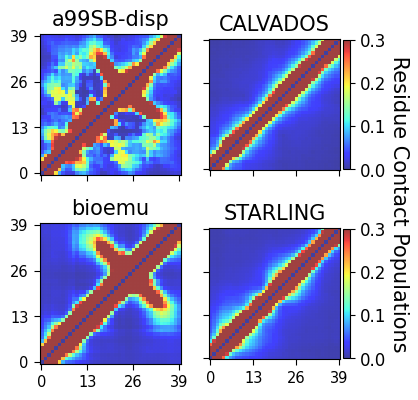

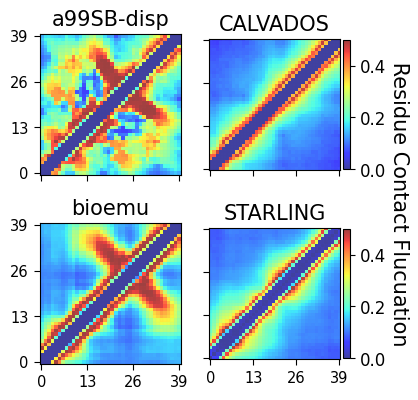

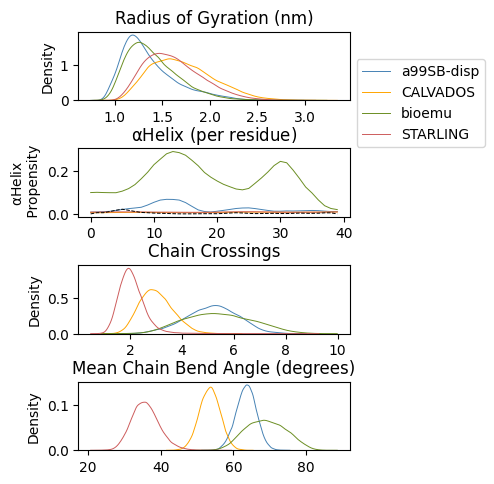

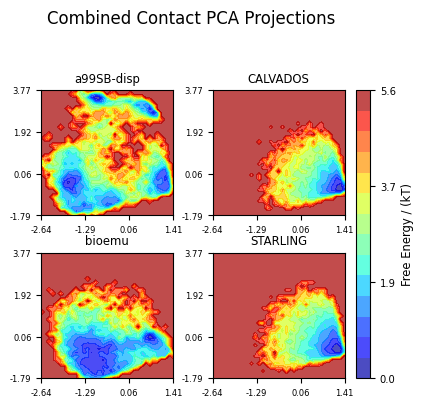

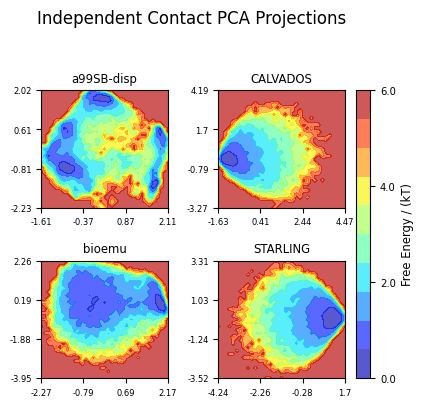

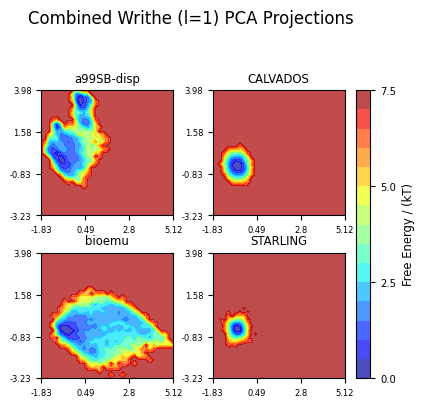

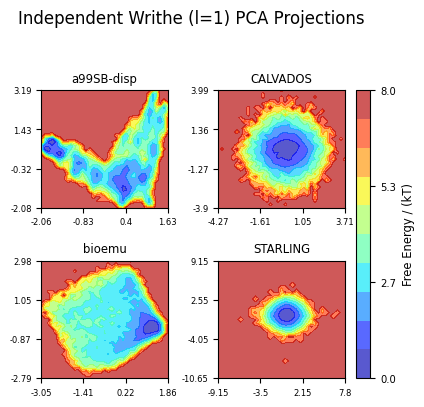

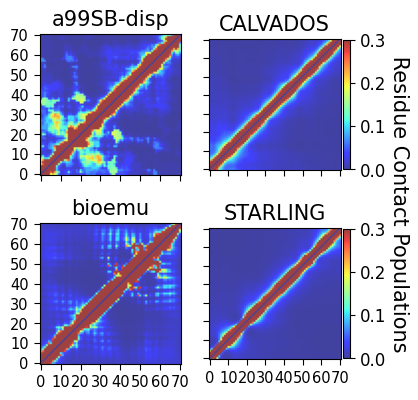

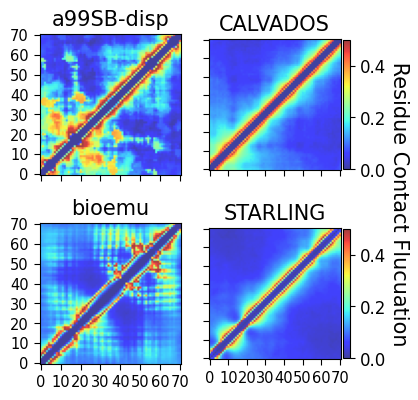

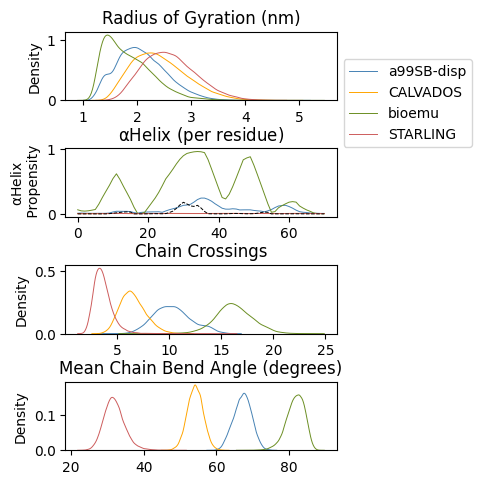

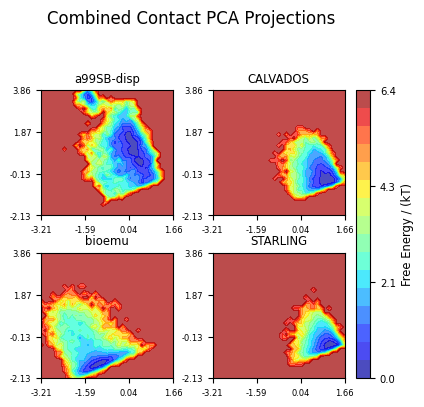

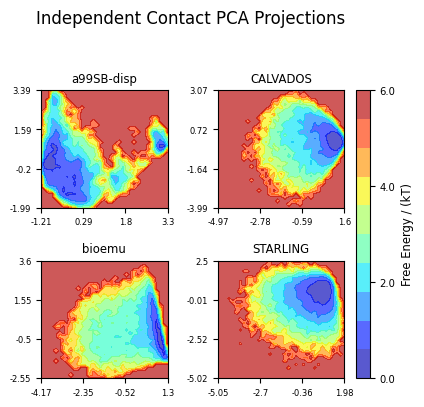

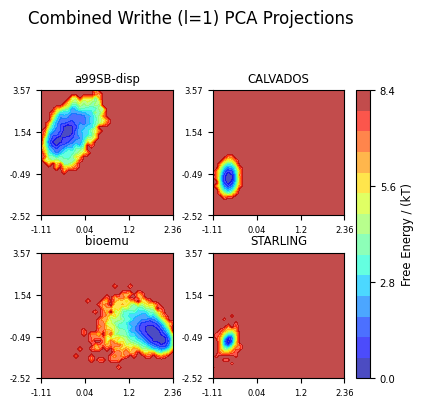

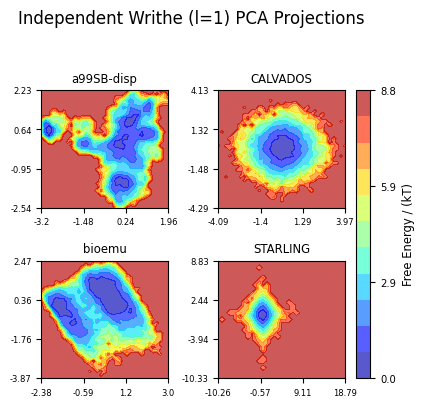

In [81]:
from writhe_tools.md_tools import to_contacts

figsize = (12, 24)
title_size = 22
scale = False
dask = False
n_comp = 3
silhouettes = []
silhouettes_rmsd = []
parallel = True
max_clusters = 16

for index, ((key, value), protein, helix_file, obs_path) in enumerate(zip(files.items(),
                                                                protein_names[:2],
                                                                helix_pdbs, obs_paths)):


    exp = join_tuples([proc_exp_data(i) for i in lsdir(obs_path, 'exp')])
    top = md.load(value['pdb'][0])
    seq, ca_index = get_residues(top)


    d2d_helix = delta2d_helix_from_data(
        sequence=''.join(map(top.top.to_fasta()[0].__getitem__, ca_index)),
        data=exp,
        index_base=1,first_residue=1,ph="neutral",
        debug=True
        )
    d2d_helix[np.isnan(d2d_helix)]=0

  

    
    sa = []
    distances = []
    rg = []
    writhes = []
    bend_angle = []

    
    for traj, pdb in zip(value['dcd'], value['pdb']):
        
        t = md.load(traj, top=pdb, atom_indices = md.load(pdb).top.select('name CA')).center_coordinates()
        writhe = Writhe(xyz=t.xyz)
        _=writhe.compute_writhe(1, cuda=True, store_results=True)
        writhes.append(writhe.writhe_features)
        sa.append(calc_sa(t, helix_file))
        
        d = ResidueDistances(np.arange(t.xyz.shape[1]), t, periodic=False)
        distances.append(d.distances)
        
        rg.append(Rg(t.xyz))
        
        bend_angle.append(bending_angle(t.xyz))
        
        
 


    fig, axes = plt.subplots(2, 2, figsize=(4, 4.5), sharey=True, sharex=True)
    for i, (d, ax, label) in enumerate(zip(distances, axes.flat, labels)):
        plot_distance_matrix(to_distance_matrix(to_contacts(d, 1).mean(0)),
                             cbar= (i == 1 or i == 3),
                             grid=True,
                             grid_alpha=.1,
                             grid_linewidth = .05,
                             grid_color='lightgray',
                             label_stride=8,
                             vmax=.3,
                             #vmin=0.01,
                             cmap='jet',
                             alpha = .75,
                             # xticks = np.arange(1, 72),
                             # yticks = np.arange(1, 72),
                             cbar_label='                              Residue Contact Populations' if i ==1 else '',
                             font_scale=1.5,
                             ax=ax,
                             title=label)


    fig, axes = plt.subplots(2, 2, figsize=(4, 4.5), sharey=True, sharex=True)
    for i, (d, ax, label) in enumerate(zip(distances, axes.flat, labels)):
        plot_distance_matrix(to_distance_matrix(to_contacts(d, 1).std(0)),
                             cbar= (i == 1 or i == 3),
                             grid=True,
                             grid_alpha=.1,
                             grid_linewidth = .05,
                             grid_color='lightgray',
                             label_stride=8,
                             vmax=.5,
                             #vmin=0.01,
                             cmap='jet',
                             alpha = .75,
                             # xticks = np.arange(1, 72),
                             # yticks = np.arange(1, 72),
                             cbar_label='                              Residue Contact Flucuation' if i ==1 else '',
                             font_scale=1.5,
                             ax=ax,
                             title=label)
    wr, ba = [abs(i).sum(1) for i in writhes], [i.mean(1) for i in bend_angle]

    lw = .7
    fig, axes = plt.subplots(4, 1, figsize=(3.5, 4.5), sharey=False, sharex=False)
    
    for i, ax, feature, xlabel in zip(
        [rg, sa, wr, ba],
        axes.flat,
        'Radius of Gyration (nm),sa,Chain Crossings,Mean Chain Bend Angle (degrees)'.split(','),
        ['nm', 'Residue', 'Total Chain Crossings', 'Degrees']
    ):
        for j, label, color in zip(i, labels, colors):
            if feature == 'sa':
                ax.plot(interp_sa(j).mean(0), color=color, lw=lw)
                ax.set_title(r'$\alpha$Helix (per residue)')
            else:
                kdeplot(j, label=label, ax=ax, color=color, lw=lw)
                ax.set_title(feature)
            # if feature == 'Radius of Gyration (nm)':
            #     ax.axvline(j.mean(), color=color, lw = .5)
            #     ax.axvline(2.4, color='black', ls='--', lw=.7)
    
        
    
        #ax.set_xlabel(xlabel, fontsize=12, labelpad=0.1)
       
    
    ax = axes.flat
    ax[1].plot(d2d_helix, color='black', lw=lw, label='Experiment', ls='--')
    ax[1].set_ylabel(r'$\alpha$Helix'+'\n Propensity')
    ax[0].legend(bbox_to_anchor=[1,.7], ncol=1)
    # ax[0].set_xlim(1, 4.5)
    # ax[1].set_ylim(0)
    # ax[1].set_xlim(0, 70)
    # ax[2].set_xlim(0,23)
    # ax[3].set_xlim(22,90)
    fig.subplots_adjust(
        top=0.93,
        bottom=0.00,
        hspace=0.7)

    pcas = [pca(sigmoid(i, scale=3), scale_projection=True, n_comp=2)[0] for i in distances]
    pcas_comb = pca(sigmoid(np.concatenate([i[stride_indices(len(i), 10000)] for i in distances], 0), scale=3),
                    scale_projection=True, n_comp=2)[0]
    
    #indices = np.array_split(np.arange(sum(map(len, distances))), np.cumsum(np.fromiter(map(len, distances), int))[:-1])
    indices = np.array_split(np.arange(10000 * 4), 4)
    
    subplots_fes2d(pcas_comb, 
                    2, 2, 
                    dscrs=labels, 
                    indices_list=indices,
                   share_extent=True,
                   bins=35,
                   alpha_contours=.7,
                   n_contours=15, 
                   hspace=0.3,
                   wspace=0.3,
                   figsize=(4, 4.5),title='Combined Contact PCA Projections')
    
    subplots_fes2d(pcas, 2, 2, 
                   dscrs=labels,
                   share_extent=False,
                   bins=35,
                   alpha_contours=.65,
                   n_contours=10, 
                   hspace=0.45,
                   wspace=0.4,
                   contour_lines=True,
                   alpha_lines=.005,figsize=(4, 4.5),
                  title='Independent Contact PCA Projections')

    
    pcas = [pca(i, scale_projection=True, n_comp=2)[0] for i in writhes]
    pcas_comb = pca(np.concatenate([i[stride_indices(len(i), 10000)] for i in writhes], 0), scale_projection=True, n_comp=2)[0]
    
    #indices = np.array_split(np.arange(sum(map(len, distances))), np.cumsum(np.fromiter(map(len, distances), int))[:-1])
    indices = np.array_split(np.arange(10000 * 4), 4)
    
    subplots_fes2d(pcas_comb, 
                    2, 2, 
                    dscrs=labels, 
                    indices_list=indices,
                   share_extent=True,
                   bins=35,
                   alpha_contours=.7,
                   n_contours=15, 
                   hspace=0.3,
                   wspace=0.3,
                   figsize=(4, 4.5),title='Combined Writhe (l=1) PCA Projections')
    
    subplots_fes2d(pcas, 2, 2, 
                   dscrs=labels,
                   share_extent=False,
                   bins=35,
                   alpha_contours=.65,
                   n_contours=10, 
                   hspace=0.45,
                   wspace=0.4,
                   contour_lines=True,
                   alpha_lines=.005,figsize=(4, 4.5),
                  title='Independent Writhe (l=1) PCA Projections')

#plt.savefig('distributions.png', dpi=800, bbox_inches='tight')

#fig.tight_layout()












    
   

In [ ]:
from writhe_tools.md_tools import resuidue_types

def hydrophobic_bools(pdb):
    top = md.load(pdb);# traj = traj_slice(traj, traj.top.select('name CA'))
    residues = np.array([top.atom(i).residue(i) for i in top.n_residues])
    return np.isin(residues, residue_types['hyprophobic'])

In [59]:
features = [
    r"$Wr_{l=1}$",
    r"$Wr_{l=3}$",
    r"$Wr_{l=5}$",
    r"$Wr_{l=1,3}$",
    r"$Wr_{l=1,3,5}$",
    "Distances",
    "Contacts",
]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2), sharey=True)
for i, (ax, protein) in enumerate(zip(axes.flat, protein_names[:-1])):
    
    scores = np.asarray(silhouettes[i])
    annotated_matrix_plot(scores[..., 0].astype(int), 
                          color_matrix=scores[..., 1],
                          yticks=names, xticks=features,
                          title=f'{protein} : Optimal Number of Clusters',
                         font_scale=.2, figsize=(3, 2), cbar_label='Silhouette Scores' if i else '', xticks_rotation=90, 
                         cmap='coolwarm', ylabel='Ensemble' if not i else '',
                          xlabel='Features', 
                         grid=True, alpha=.93,ax=ax)
#fig.tight_layout()

for pdb, dcd in zip(*files['asyn'].values()):
    traj = md.load(dcd, top=pdb, atom_indices = md.load(pdb).top.select('name CA'))
    print(traj.n_frames)

In [60]:
traj = md.load(files['ab40']['dcd'][0],
                        top=files['ab40']['pdb'][0],
                        ).center_coordinates()

atom_indices = md.load(files['ab40']['pdb'][0]).top.select('name CA')

writhe = Writhe(traj_slice(traj, 'name CA').xyz)

In [61]:
rmsd_matrices

array([['./rmsd_matrices/rmsd_matrix_A$\\beta$40_a99.npy',
        './rmsd_matrices/rmsd_matrix_A$\\beta$40_CALVADOS.npy',
        './rmsd_matrices/rmsd_matrix_A$\\beta$40_bAIes.npy',
        './rmsd_matrices/rmsd_matrix_A$\\beta$40_BioEMU.npy',
        './rmsd_matrices/rmsd_matrix_A$\\beta$40_STARLING.npy'],
       ['./rmsd_matrices/rmsd_matrix_ACTR_a99.npy',
        './rmsd_matrices/rmsd_matrix_ACTR_CALVADOS.npy',
        './rmsd_matrices/rmsd_matrix_ACTR_bAIes.npy',
        './rmsd_matrices/rmsd_matrix_ACTR_BioEMU.npy',
        './rmsd_matrices/rmsd_matrix_ACTR_STARLING.npy']], dtype='<U51')

In [63]:
# writhes = []
removed_writhes = []
for i in (1, 3):
    writhe.compute_writhe(i, cuda=True)
    # writhes.append(writhe.features())
    removed_writhes.append(writhe.features(remove_overlap=True))

# proj = pca(np.concatenate([pca(i, scale_projection=True, n_comp=3, dask=False)[0] for i in writhes], 1),
#            n_comp=2, dask=False)[0]

projs = [pca(np.concatenate([pca(i, scale_projection=True, n_comp=3, dask=False)[0] for i in removed_writhes], 1),
           n_comp=2, dask=False)[0] for i in (2, 3, 4,5, 8)]

# proj_1 = pca(writhes[0], n_comp=2)[0]
# scores_1 = silhouette_scores(proj_1, np.arange(3, 25), parallel=True, D=np.load(rmsd_matrices[0][0]))
#scores = silhouette_scores(proj, np.arange(3, 25), parallel=True, D=np.load(rmsd_matrices[0][0])
scores = [silhouette_scores(proj, np.arange(3, 35), parallel=True, D=np.load(rmsd_matrices[0][0]))
          for proj in projs]



2026-02-25 13:02:15,403	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 
2026-02-25 13:02:59,482	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 
2026-02-25 13:03:44,018	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 
2026-02-25 13:04:28,972	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 
2026-02-25 13:05:13,173	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 


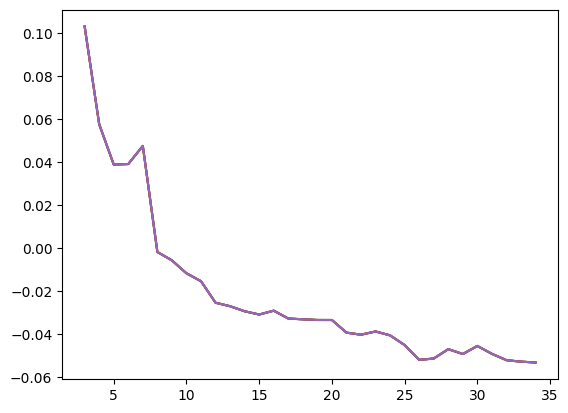

In [64]:
for i in scores:
    plt.plot(*i.T)

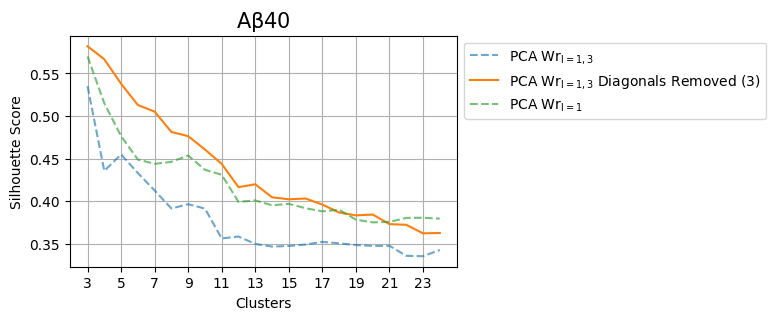

In [53]:

plt.figure(figsize=(5, 3))
plt.plot(*scores.T, label=r'PCA $Wr_{{l=1,3}}$', alpha=.65, ls='--')
plt.plot(*scores_rm.T, label=r'PCA $Wr_{{l=1,3}}$ Diagonals Removed (3)')
plt.plot(*scores_1.T, label=r'PCA $Wr_{{l=1}}$', alpha=.65, ls='--')
plt.xlabel('Clusters', )
plt.ylabel('Silhouette Score')
plt.xticks(np.arange(3, 25)[::2], np.arange(3, 25)[::2])
plt.legend(bbox_to_anchor=[1,1])
plt.title(protein_names[0], size=15)
plt.grid()

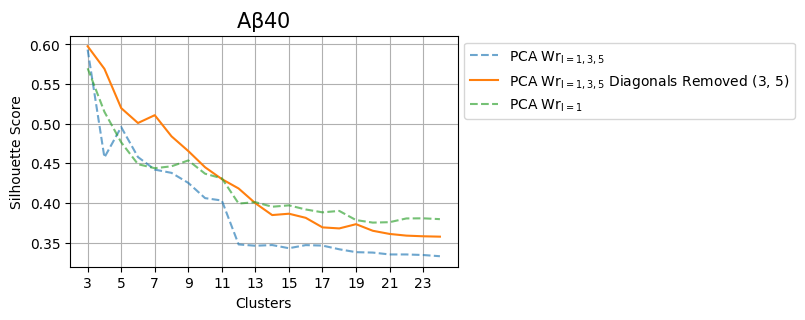

In [40]:

plt.figure(figsize=(5, 3))
plt.plot(*scores.T, label=r'PCA $Wr_{{l=1,3,5}}$', alpha=.65, ls='--')
plt.plot(*scores_rm.T, label=r'PCA $Wr_{{l=1,3,5}}$ Diagonals Removed (3, 5)')
plt.plot(*scores_1.T, label=r'PCA $Wr_{{l=1}}$', alpha=.65, ls='--')
plt.xlabel('Clusters', )
plt.ylabel('Silhouette Score')
plt.xticks(np.arange(3, 25)[::2], np.arange(3, 25)[::2])
plt.legend(bbox_to_anchor=[1,1])
plt.title(protein_names[0], size=15)
plt.grid()

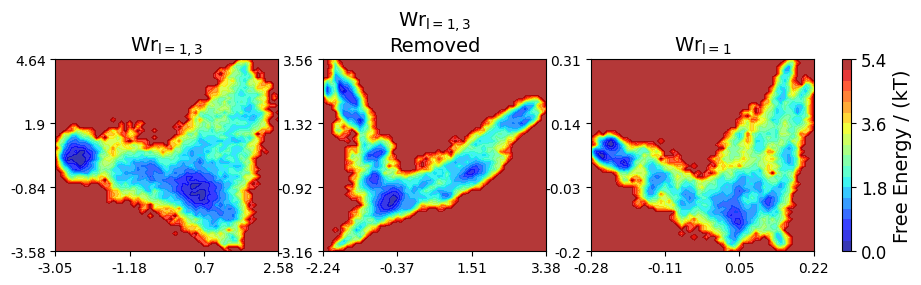

In [55]:
subplots_fes2d([proj, proj_rm, proj_1], 1, 3 , [features[-4], features[-4]+'\nRemoved', features[0]],
               figsize=(10, 3), bins=55, n_contours=18, share_extent=False, alpha_contours=.78, font_scale=1, )

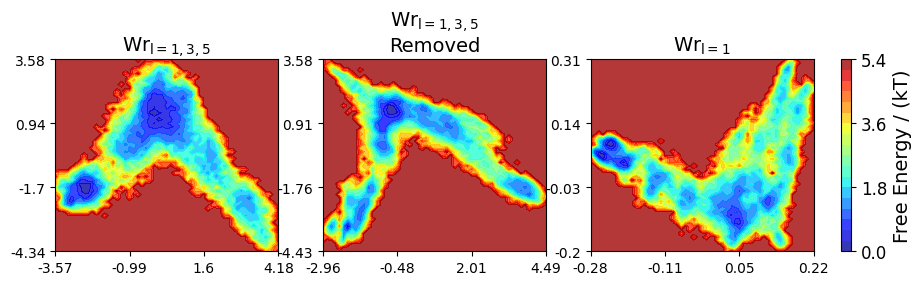

In [50]:
subplots_fes2d([proj, proj_rm, proj_1], 1, 3 , [features[-3], features[-3]+'\nRemoved', features[0]],
               figsize=(10, 3), bins=55, n_contours=18, share_extent=False, alpha_contours=.78, font_scale=1, )

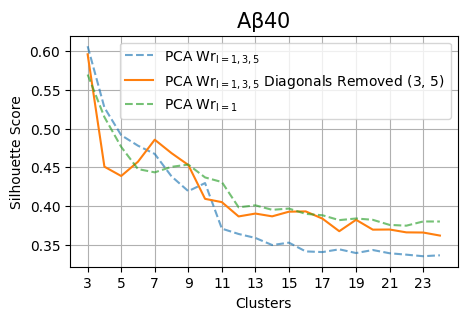

In [36]:

plt.figure(figsize=(5, 3))
plt.plot(*scores.T, label=r'PCA $Wr_{{l=1,3,5}}$', alpha=.65, ls='--')
plt.plot(*scores_rm.T, label=r'PCA $Wr_{{l=1,3,5}}$ Diagonals Removed (3, 5)')
plt.plot(*scores_1.T, label=r'PCA $Wr_{{l=1}}$', alpha=.65, ls='--')
plt.xlabel('Clusters', )
plt.ylabel('Silhouette Score')
plt.xticks(np.arange(3, 25)[::2], np.arange(3, 25)[::2])
plt.legend(bbox_to_anchor=[1,1])
plt.title(protein_names[0], size=15)
plt.grid()

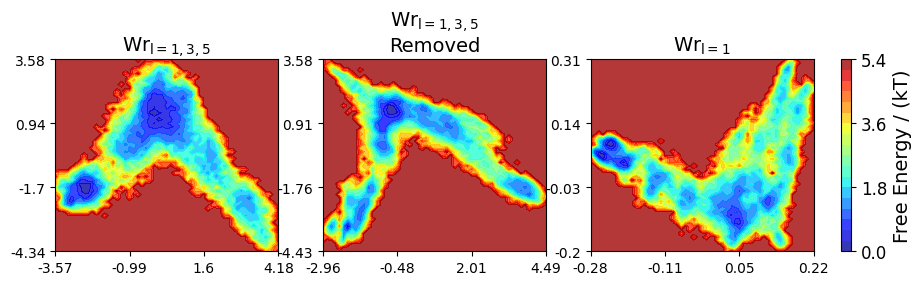

In [49]:
subplots_fes2d([proj, proj_rm, proj_1], 1, 3 , [features[-3], features[-3]+'\nRemoved', features[0]],
               figsize=(10, 3), bins=55, n_contours=18, share_extent=False, alpha_contours=.78, font_scale=1)
#plt.tight_layout()